<a href="https://colab.research.google.com/github/KurizuXX/Data-Science-Assessment/blob/main/notebooks/evaluacion_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluacion 1 - Programacion para la ciencia de datos

In [2]:
# IMPORTES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [3]:
# Lectura de dataset

df = pd.read_csv('/content/googleplaystore.csv')
df_rev = pd.read_csv('/content/googleplaystore_user_reviews.csv')

In [ ]:
# Lectura de df

df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# Lectura de df_rev

df_rev.head(5)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [4]:
# Union de Dataframes
# Se utiliza "pd.merge" junto con "on='App', how='inner'" para asegurarse que
# solo se incluyan las filas en las cuales la app sea la misma, es decir, que las reviews del dataframe2 correspondan con las apps del dataframe1

df_full = pd.merge(df, df_rev, on='App', how='inner')
df_full.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000


## Ahora, con un df completo, podemos comenzar a trabajar.

- Comenzamos haciendo una revision sencilla de los datos, para saber mas o menos con que trabajaremos

In [ ]:
# info del df

df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122662 entries, 0 to 122661
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   App                     122662 non-null  object 
 1   Category                122662 non-null  object 
 2   Rating                  122622 non-null  float64
 3   Reviews                 122662 non-null  object 
 4   Size                    122662 non-null  object 
 5   Installs                122662 non-null  object 
 6   Type                    122662 non-null  object 
 7   Price                   122662 non-null  object 
 8   Content Rating          122662 non-null  object 
 9   Genres                  122662 non-null  object 
 10  Last Updated            122662 non-null  object 
 11  Current Ver             122662 non-null  object 
 12  Android Ver             122662 non-null  object 
 13  Translated_Review       72605 non-null   object 
 14  Sentiment           

In [ ]:
# Descripcion del df

df_full.describe()

,Rating,Sentiment_Polarity,Sentiment_Subjectivity
count,122622.000000,72615.000000,72615.000000
mean,4.322405,0.157320,0.494162
std,0.284766,0.332652,0.240144
min,2.500000,-1.000000,0.000000
25%,4.200000,0.000000,0.380000
50%,4.400000,0.129167,0.509740
75%,4.500000,0.356250,0.633333
max,4.900000,1.000000,1.000000


In [5]:
# Revisamos el total de datos

df_full.shape
print("Total de datos:",df_full.shape[0],"filas")

Total de datos: 122662 filas


### Identificar tipos de columnas (Numéricas y Categóricas)

In [ ]:
# Muestra los tipos de datos de todas las columnas
print(df_full.dtypes)

App                        object
Category                   object
Rating                    float64
Reviews                    object
Size                       object
Installs                   object
Type                       object
Price                      object
Content Rating             object
Genres                     object
Last Updated               object
Current Ver                object
Android Ver                object
Translated_Review          object
Sentiment                  object
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
dtype: object


Con esto podemos ver las columnas que son numéricas (`float64`) y las que son de tipo objeto (`object`), que suelen ser categóricas o cadenas de texto. Las columnas `Translated_Review` y `Sentiment` son ejemplos de columnas categóricas, mientras que `Rating`, `Sentiment_Polarity` y `Sentiment_Subjectivity` son numéricas.

### Identificamos Outliers en las columnas numericas

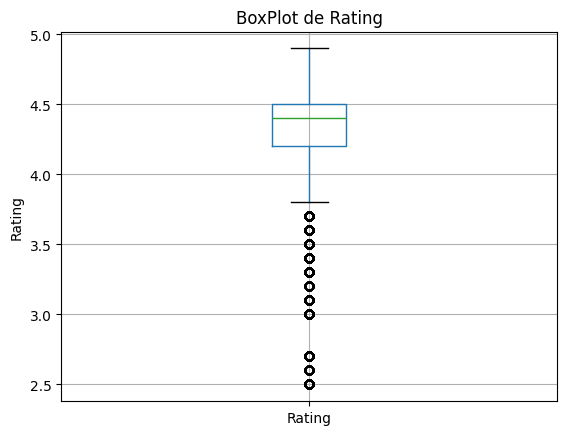

In [ ]:
# Outliers en Rating
df_full.boxplot(column=['Rating'])
plt.title('BoxPlot de Rating')
plt.ylabel('Rating')
plt.show()

- La mayoría de las aplicaciones tienen una calificación alta, con la mediana alrededor de 4.3-4.4.
- La distribución es bastante compacta, lo que indica que la mayoría de las calificaciones se agrupan en un rango estrecho.
- Hay outliers significativos en el extremo inferior (ratings más bajos), lo que sugiere que existen aplicaciones con calificaciones considerablemente peores que la media.

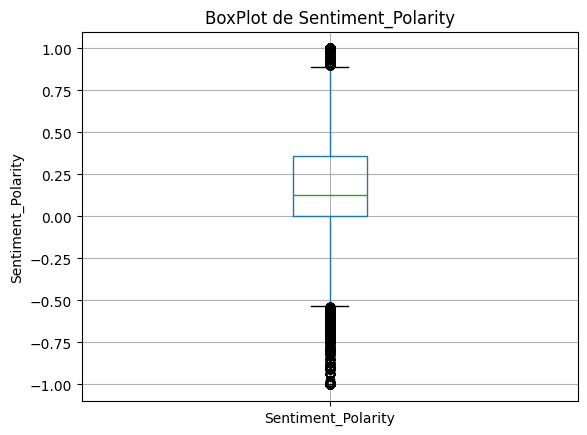

In [ ]:
# Outliers en Sentiment_Polarity
df_full.boxplot(column=['Sentiment_Polarity'])
plt.title('BoxPlot de Sentiment_Polarity')
plt.ylabel('Sentiment_Polarity')
plt.show()

- La mediana se encuentra cerca de 0, lo que indica que la mayoría de las reseñas tienen una polaridad de sentimiento neutra.
- La caja es relativamente ancha, mostrando una dispersión considerable de los sentimientos (desde negativos a positivos).
- Se observan muchos outliers tanto en el extremo positivo (sentimientos muy positivos) como en el negativo (sentimientos muy negativos), lo cual es normal en el análisis de sentimientos donde las opiniones pueden ser muy extremas.

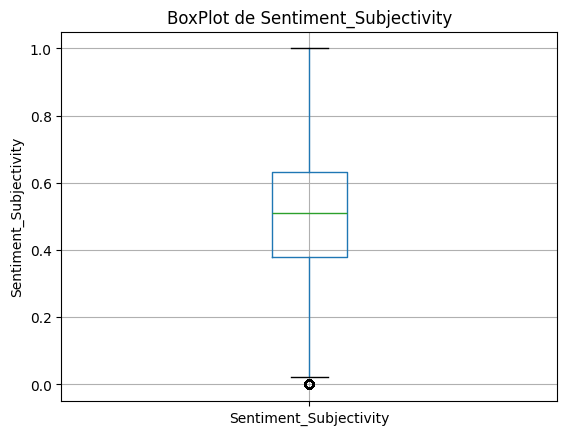

In [ ]:
# Outliers en Sentiment_Subjectivity
df_full.boxplot(column=['Sentiment_Subjectivity'])
plt.title('BoxPlot de Sentiment_Subjectivity')
plt.ylabel('Sentiment_Subjectivity')
plt.show()

- La mediana se ubica entre 0.5 y 0.6, sugiriendo que una buena parte de las reseñas tienen un grado moderado de subjetividad.
- La distribución de la subjetividad es bastante amplia.
- También se aprecian outliers en ambos extremos, especialmente en los valores más bajos (cercanos a 0), lo que podría indicar reseñas muy objetivas o basadas en hechos, mientras que los valores más altos representan reseñas muy subjetivas y basadas en opiniones personales.

### Una vez hecho esto, pasamos a identificar las columnas con valores faltantes

In [6]:
datos_faltantes = df_full.isnull().sum()
print(datos_faltantes)

App                           0
Category                      0
Rating                       40
Reviews                       0
Size                          0
Installs                      0
Type                          0
Price                         0
Content Rating                0
Genres                        0
Last Updated                  0
Current Ver                   0
Android Ver                   0
Translated_Review         50057
Sentiment                 50047
Sentiment_Polarity        50047
Sentiment_Subjectivity    50047
dtype: int64


In [7]:
# Total de datos (en este contexto celdas de datos) faltantes
total_faltantes = datos_faltantes.sum()
print(f"Total de datos faltantes: {total_faltantes}")

Total de datos faltantes: 200238


- Podemos notar que tenemos una gran cantidad de datos faltantes

### Ahora revisamos si tenemos datos duplicados

In [8]:
#Aquí revisamos y mostramos un ejemplo de comprobación de filas duplicadas.
datos_duplicados = df_full.duplicated().sum
print(datos_duplicados)

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
122657     True
122658     True
122659     True
122660     True
122661     True
Length: 122662, dtype: bool>


In [9]:
#Revisamos las columnas que estan duplicadas
columnas_duplicadas = df_full[df_full.duplicated()]
columnas_duplicadas

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
6,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
12,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
21,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
22,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
24,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122657,FP Notebook,MEDICAL,4.5,410,60M,"50,000+",Free,0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up,NaN,NaN,NaN,NaN
122658,FP Notebook,MEDICAL,4.5,410,60M,"50,000+",Free,0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up,NaN,NaN,NaN,NaN
122659,FP Notebook,MEDICAL,4.5,410,60M,"50,000+",Free,0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up,NaN,NaN,NaN,NaN
122660,FP Notebook,MEDICAL,4.5,410,60M,"50,000+",Free,0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up,NaN,NaN,NaN,NaN


In [10]:
# Contamos la cantidad de duplicados
total_duplicados = columnas_duplicadas.shape[0]
print(f"Cantidad total de duplicados: {total_duplicados}")
print(f"de un total de {df_full.shape[0]} datos (filas)")

Cantidad total de duplicados: 81001
de un total de 122662 datos (filas)


- Podemos ver que también tenemos bastantes datos duplicados

### Aseguramos la integridad de los datos

In [11]:
#Primero para asegurar la integridad de los datos originales, se va a duplicar el Dataframe que vamos a usar, para tener disponible una copia del dataframe original
#en caso de que se necesite volver a él
df_copy = df_full.copy()

### Pasamos al manejo de datos duplicados y faltantes

#### Manejo de datos faltantes

In [12]:
# Vamos a rellenar los datos faltantes de la columna Rating con la media de la columna
df_copy['Rating'] = df_copy['Rating'].fillna(df_copy['Rating'].mean())

In [13]:
# Manejo de datos faltantes columnas Sentiment y Sentiment_Polarity
# Segun parece las columnas relacionadas a Sentiment estan relacionadas con las reseñas y estan codificadas por medio de StandardScaler,
# por lo que se puede rellenar estos datos con la media de cada columna, asegurando que los datos  faltantes no afectan la distribucion de los datos
df_copy['Sentiment_Polarity'] = df_copy['Sentiment_Polarity'].fillna(df_copy['Sentiment_Polarity'].mean())
df_copy['Sentiment_Subjectivity'] = df_copy['Sentiment_Subjectivity'].fillna(df_copy['Sentiment_Subjectivity'].mean())



In [14]:
datos_faltantes_copia = df_copy.isnull().sum()
print(datos_faltantes_copia)

App                           0
Category                      0
Rating                        0
Reviews                       0
Size                          0
Installs                      0
Type                          0
Price                         0
Content Rating                0
Genres                        0
Last Updated                  0
Current Ver                   0
Android Ver                   0
Translated_Review         50057
Sentiment                 50047
Sentiment_Polarity            0
Sentiment_Subjectivity        0
dtype: int64


In [15]:
df_copy.shape

(122662, 17)

- Los datos que quedan por rellenar corresponden a reseñas de las aplicaciones, las cuales no se pueden rellenar por medio de funciones de pandas, por lo que se debe tomar una decision si estas filas se deben conservar o eliminar


#### Manejo de datos duplicados

- Se decidió eliminar la columnas "Translated_Review" ya que posee una gran cantidad de datos nulos, y los datos que da no son relevantes, al ser más importantes los datos que nos proporcionan las columnas "Sentiment_Polarity" y "Sentiment_Subjectivity" debido especialmente a que son datos procesados adecuados para un modelo ML.

In [16]:
#Decidimos borrar la columna "Translated_Review"
df_copy = df_copy.drop(['Translated_Review'], axis=1)
print(f"Columnas ahora existentes: {df_copy.columns.tolist()}")

Columnas ahora existentes: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [17]:
# Rellenamos los valores faltantes en 'Sentiment' con un marcador de posición
# ya que suele estar ligado a la reseña
df_copy['Sentiment'] = df_copy['Sentiment'].fillna('Unknown')

# Verificamos el resultado
print(f"Cantidad de registros preservados: {df_copy.shape[0]}")
print(f"Valores nulos en Sentiment: {df_copy['Sentiment'].isnull().sum()}")

display(df_copy.head(10))

Cantidad de registros preservados: 122662
Valores nulos en Sentiment: 0


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Negative,-0.25000,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Negative,-0.72500,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Neutral,0.00000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Unknown,0.15732,0.494162
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Positive,0.50000,0.600000
5,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Negative,-0.80000,0.900000
6,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Unknown,0.15732,0.494162
7,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Neutral,0.00000,0.000000
8,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Positive,0.50000,1.000000
9,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,Positive,0.50000,0.600000


- Se decidio preservar la columna "Sentiment" porque si se eliminaban se perdian mas de 100.000 datos, pero más que eso nos permite obtener métricas interesantes.

### Codificacion de datos

#### Antes de comenzar a codificar, identificamos las columnas de tipo object

In [18]:
# Identificar columnas de tipo 'object'
object_columns = df_full.select_dtypes(include='object').columns
print("Columnas de tipo 'object' (candidatas para codificación o limpieza):")
print(object_columns)

Columnas de tipo 'object' (candidatas para codificación o limpieza):
Index(['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Translated_Review', 'Sentiment'],
      dtype='object')


#### Paso 1: Limpieza y Conversión de Columnas Numéricas

Algunas columnas como `Installs`, `Price` y `Reviews` tienen caracteres especiales que impiden que sean tratadas como números. Vamos a limpiarlas.

In [19]:
# 1. Limpiar columna 'Installs': quitar '+' y ','
df_copy['Installs'] = df_copy['Installs'].str.replace('+', '').str.replace(',', '').astype(int)

In [20]:
# 2. Limpiar columna 'Price': quitar '$'
df_copy['Price'] = df_copy['Price'].str.replace('$', '').astype(float)

In [21]:
# 3. Convertir 'Reviews' a numérico
df_copy['Reviews'] = pd.to_numeric(df_copy['Reviews'], errors='coerce')

In [22]:
# Verificamos los cambios
display(df_copy[['Installs', 'Price', 'Reviews']].head())
print(df_copy[['Installs', 'Price', 'Reviews']].dtypes)

,Installs,Price,Reviews
0,500000,0.0,967
1,500000,0.0,967
2,500000,0.0,967
3,500000,0.0,967
4,500000,0.0,967


Installs      int64
Price       float64
Reviews       int64
dtype: object


Ahora que estas columnas son numéricas, podemos proceder en el siguiente paso a codificar las variables realmente categóricas como `Type` o `Content Rating`.

#### Como extra, codificamos la columna "Last Updated"

In [23]:
# Convertimos la columna 'Last Updated' a formato datetime
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])

# Verificamos el cambio visualizando las primeras filas
display(df_copy[['App', 'Last Updated']].head())

,App,Last Updated
0,Coloring book moana,2018-01-15
1,Coloring book moana,2018-01-15
2,Coloring book moana,2018-01-15
3,Coloring book moana,2018-01-15
4,Coloring book moana,2018-01-15


#### Paso 2: Codificación de Variables Categóricas

Utilizaremos `OneHotEncoder` para las categorías nominales y `LabelEncoder` para simplificar otras columnas.

In [24]:
# 1. Encoding custom para 'Sentiment'

# se define el mapeo custom para "Sentiment"
mapeo_sentiment = {
    'Unknown': 0,
    'Negative': 1,
    'Neutral': 2,
    'Positive': 3
}

# Se aplica el mapeo
df_copy['Sentiment_Encoded'] = df_copy['Sentiment'].map(mapeo_sentiment)


In [25]:
# 2. One-Hot Encoding para 'Type' y 'Content Rating'
# Usamos pandas get_dummies por simplicidad en este paso
df_copy = pd.get_dummies(df_copy, columns=['Type', 'Content Rating'], prefix=['Type', 'Content'])

In [26]:
# Verificamos las nuevas columnas generadas
print("Nuevas columnas después de la codificación:")
display(df_copy.filter(regex='Type_|Content_|Sentiment_Encoded').head())

Nuevas columnas después de la codificación:


,Sentiment_Encoded,Type_Free,Type_Paid,Content_Adults only 18+,Content_Everyone,Content_Everyone 10+,Content_Mature 17+,Content_Teen
0,1,True,False,False,True,False,False,False
1,1,True,False,False,True,False,False,False
2,2,True,False,False,True,False,False,False
3,0,True,False,False,True,False,False,False
4,3,True,False,False,True,False,False,False


Con esto, las categorías ahora son representadas numéricamente, lo que permite que los modelos de machine learning puedan interpretar estas características.

In [27]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Price,Genres,Last Updated,Current Ver,...,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Encoded,Type_Free,Type_Paid,Content_Adults only 18+,Content_Everyone,Content_Everyone 10+,Content_Mature 17+,Content_Teen
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,0.0,Art & Design;Pretend Play,2018-01-15,2.0.0,...,-0.25000,1.000000,1,True,False,False,True,False,False,False
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,0.0,Art & Design;Pretend Play,2018-01-15,2.0.0,...,-0.72500,0.833333,1,True,False,False,True,False,False,False
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,0.0,Art & Design;Pretend Play,2018-01-15,2.0.0,...,0.00000,0.000000,2,True,False,False,True,False,False,False
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,0.0,Art & Design;Pretend Play,2018-01-15,2.0.0,...,0.15732,0.494162,0,True,False,False,True,False,False,False
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,0.0,Art & Design;Pretend Play,2018-01-15,2.0.0,...,0.50000,0.600000,3,True,False,False,True,False,False,False


### Aseguramos la integridad de los datos

In [28]:
#Con los datos ya limpios y corregidos, podemos empezar a trabajar con métricas.
#Para eso, creamos un nuevo DataFrame a partir de "df_copy"
df_clean = df_copy.copy()

### Cálculo de la Matriz de Correlación

Calculamos la correlación entre las variables numéricas para identificar relaciones (positivas o negativas) entre las características del dataset.

In [29]:
# Calculamos la correlación solo para las columnas numéricas
correlation_matrix = df_clean.select_dtypes(include=[np.number]).corr()

In [30]:
# Visualizamos la matriz
display(correlation_matrix)

,Rating,Reviews,Installs,Price,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Encoded
Rating,1.000000,0.151473,-0.000993,-0.087663,0.039414,0.043222,0.061431
Reviews,0.151473,1.000000,0.405630,-0.029038,-0.088559,-0.014838,0.012155
Installs,-0.000993,0.405630,1.000000,-0.031567,-0.046093,-0.007861,0.000093
Price,-0.087663,-0.029038,-0.031567,1.000000,0.014708,0.004014,-0.020053
Sentiment_Polarity,0.039414,-0.088559,-0.046093,0.014708,1.000000,0.227551,0.363850
Sentiment_Subjectivity,0.043222,-0.014838,-0.007861,0.004014,0.227551,1.000000,0.073184
Sentiment_Encoded,0.061431,0.012155,0.000093,-0.020053,0.363850,0.073184,1.000000


## Apartado de gráficos y metricas

### Análisis Exploratorio de Datos (EDA)
A continuación, presentamos una serie de visualizaciones clave para entender la distribución y comportamiento de las aplicaciones utilizando nuestro dataset limpio (`df_clean`).


### 1. Grafico de calor

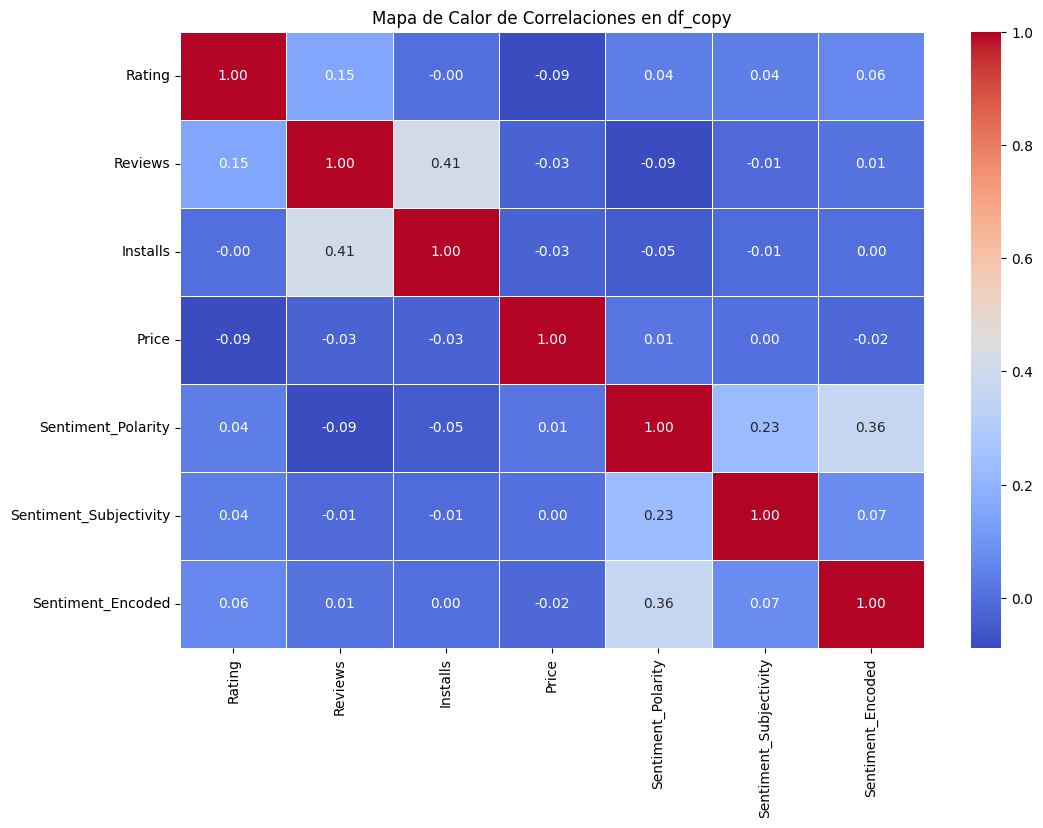

In [31]:
# Visualización con un mapa de calor para mejor interpretación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones en df_copy')
plt.show()

### 2. Desbloqueo de Relaciones: Evolución de la Matriz de Correlación
Antes de la limpieza, variables como `Reviews`, `Installs` y `Price` eran cadenas de texto (strings con comas, signos '+' o '$'). Por lo tanto, el sistema no podía encontrar correlaciones matemáticas entre ellas. Al limpiarlas, desbloqueamos un análisis multivariable completo.

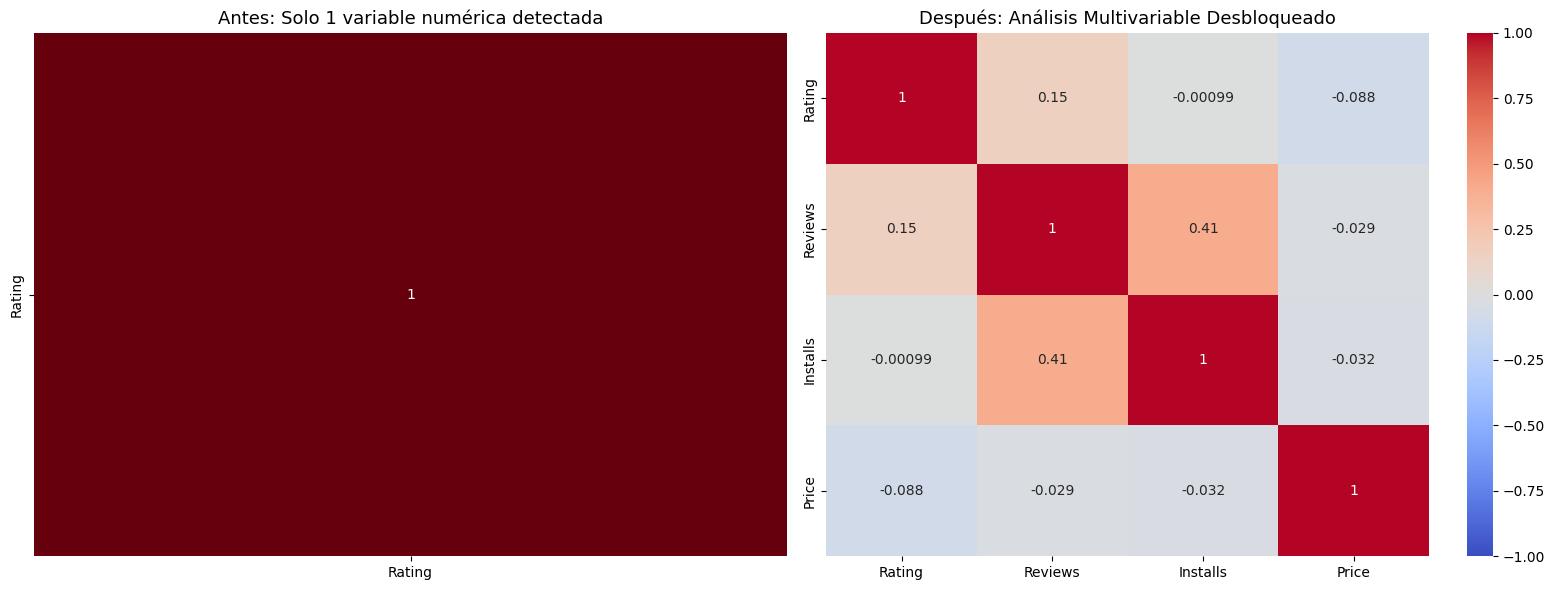

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANTES: Seleccionamos solo las variables numéricas del dataset sucio
# (Normalmente, solo Rating se detecta como numérica al principio)
corr_antes = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_antes, annot=True, cmap='Reds', ax=axes[0], cbar=False, vmin=-1, vmax=1)
axes[0].set_title('Antes: Solo 1 variable numérica detectada', fontsize=13)

# DESPUÉS: Seleccionamos las numéricas del dataset limpio (que ya convertimos)
columnas_numericas = ['Rating', 'Reviews', 'Installs', 'Price']
corr_despues = df_copy[columnas_numericas].corr()
sns.heatmap(corr_despues, annot=True, cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Después: Análisis Multivariable Desbloqueado', fontsize=13)

plt.tight_layout()
plt.show()

### 3. Sentimientos por Categoría (Top 10 categorías con más reseñas)

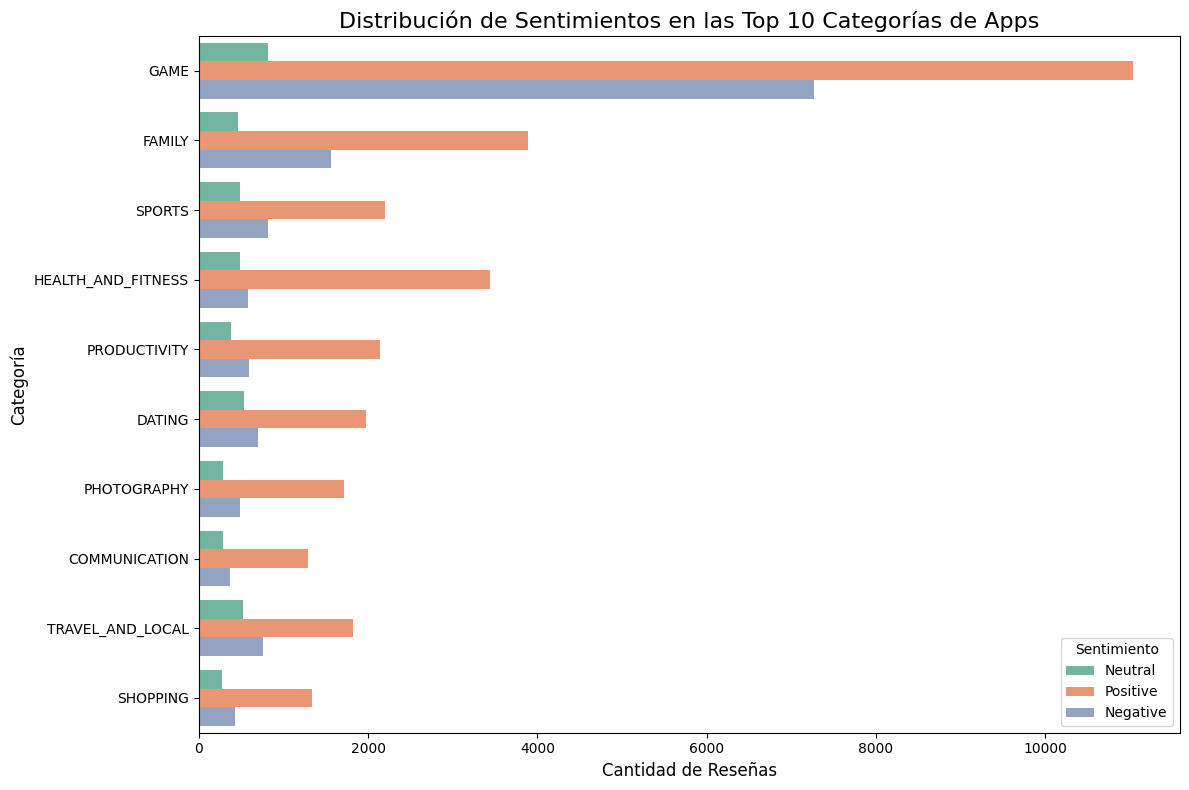

In [32]:
plt.figure(figsize=(12, 8))

# Filtramos para quedarnos con las 10 categorías principales para no saturar el gráfico
top_10_categorias = df_full['Category'].value_counts().index[:10]
df_top_cats = df_full[df_full['Category'].isin(top_10_categorias)]

# Creamos el gráfico agrupado
sns.countplot(data=df_top_cats, y='Category', hue='Sentiment', palette='Set2',
              order=top_10_categorias)

plt.title('Distribución de Sentimientos en las Top 10 Categorías de Apps', fontsize=16)
plt.xlabel('Cantidad de Reseñas', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.legend(title='Sentimiento', loc='lower right')
plt.tight_layout()

# Guardar y mostrar
plt.show()

### 4. Categorías más populares
El siguiente gráfico muestra cuáles son las 10 categorías que concentran la mayor cantidad de aplicaciones en la tienda.

/tmp/ipykernel_1243/2558978462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df_clean,


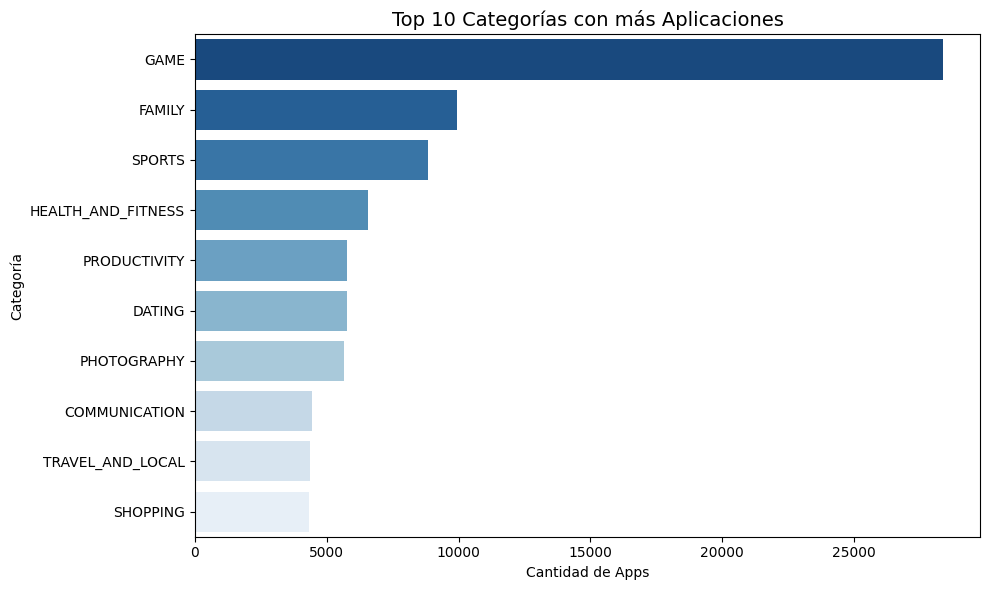

In [33]:
plt.figure(figsize=(10, 6))

# Usamos countplot para contar automáticamente y order para ordenar de mayor a menor
sns.countplot(y='Category', data=df_clean,
              order=df_clean['Category'].value_counts().index[:10],
              palette='Blues_r')

plt.title('Top 10 Categorías con más Aplicaciones', fontsize=14)
plt.xlabel('Cantidad de Apps')
plt.ylabel('Categoría')

plt.tight_layout()
plt.show()

### 5. Relación entre Precio y Rating (Solo Apps de Pago)
#### Filtramos solo las apps de pago (Price > 0)

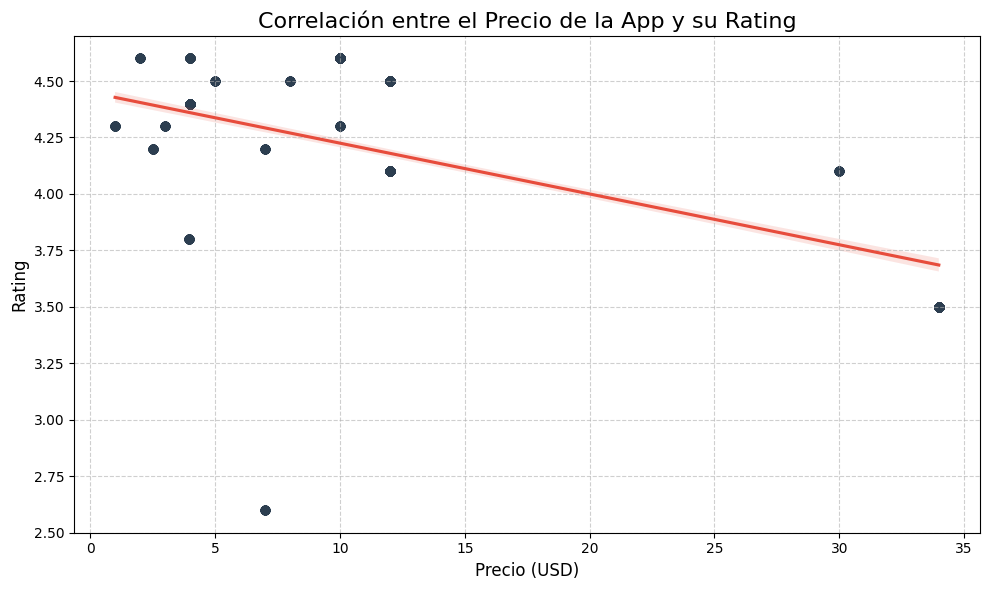

In [34]:

apps_de_pago = df_copy[df_clean['Price'] > 0]

plt.figure(figsize=(10, 6))

# Un regplot dibuja los puntos y además calcula una línea de tendencia lineal
sns.regplot(x='Price', y='Rating', data=apps_de_pago,
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'},
            line_kws={'color':'#e74c3c'})

plt.title('Correlación entre el Precio de la App y su Rating', fontsize=16)
plt.xlabel('Precio (USD)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 6. Relación entre la Calificación (Rating) y la Cantidad de Reseñas
¿Las aplicaciones con mejores calificaciones suelen tener más reseñas? Este gráfico de dispersión nos ayuda a identificar si existe algún patrón visible entre ambas variables.

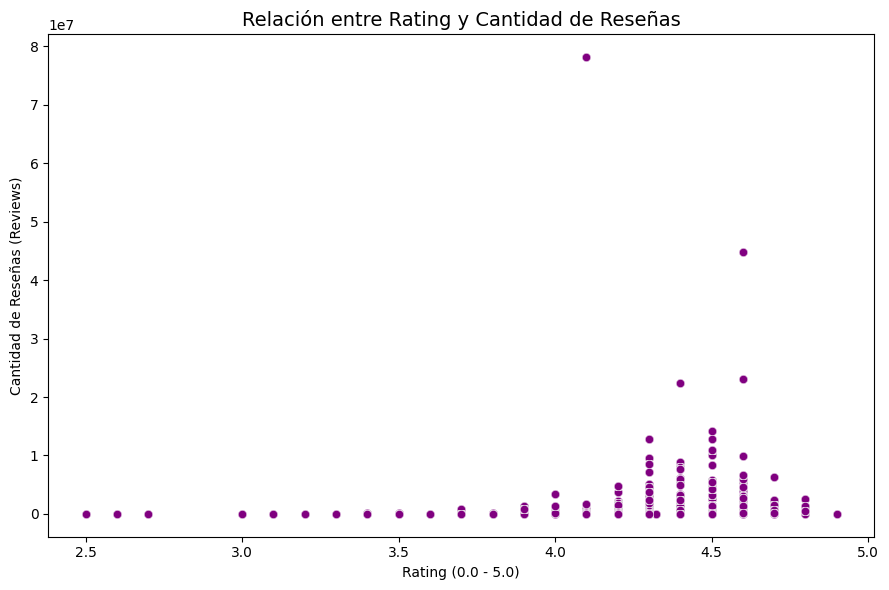

In [35]:
plt.figure(figsize=(9, 6))

# Gráfico de puntos básico
sns.scatterplot(x='Rating', y='Reviews', data=df_copy, color='purple', alpha=0.5)

plt.title('Relación entre Rating y Cantidad de Reseñas', fontsize=14)
plt.xlabel('Rating (0.0 - 5.0)')
plt.ylabel('Cantidad de Reseñas (Reviews)')

plt.tight_layout()
plt.show()

### 7. Proporcion de Apps

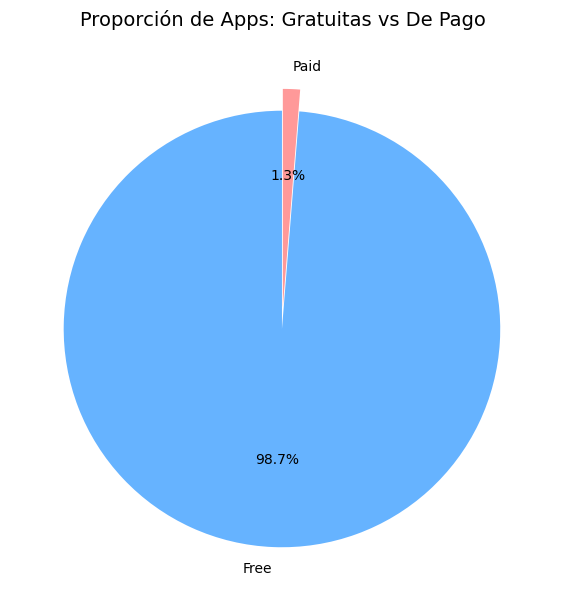

In [37]:
plt.figure(figsize=(6, 6))

# Get the counts for 'Free' and 'Paid' apps from the one-hot encoded columns
free_apps_count = df_clean['Type_Free'].sum()
paid_apps_count = df_clean['Type_Paid'].sum()

# Create a Series for the pie chart
type_counts = pd.Series({'Free': free_apps_count, 'Paid': paid_apps_count})

# Contamos los valores y generamos el gráfico circular
colores = ['#66b3ff', '#ff9999']
type_counts.plot.pie(autopct='%1.1f%%',
                                         colors=colores,
                                         startangle=90,
                                         explode=(0.1, 0)) # Explode separa un poco las partes

plt.title('Proporción de Apps: Gratuitas vs De Pago', fontsize=14)
plt.ylabel('') # Ocultamos la etiqueta del eje Y para mayor limpieza

plt.tight_layout()
plt.show()

### 8. Distribución General de Sentimientos de los Usuarios

/tmp/ipykernel_1243/3238976543.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df_clean, palette='Set2')


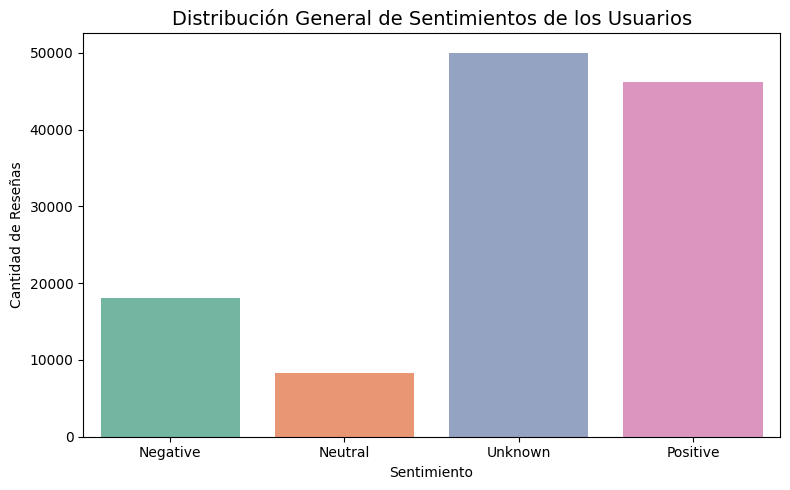

In [39]:
plt.figure(figsize=(8, 5))

# Gráfico de barras vertical para los sentimientos en df_clean
sns.countplot(x='Sentiment', data=df_clean, palette='Set2')

plt.title('Distribución General de Sentimientos de los Usuarios', fontsize=14)
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Reseñas')

plt.tight_layout()
plt.show()

### 9. Estrategia de Pricing: Distribución de precios en apps de pago
Para el equipo de monetización, es vital entender cuánto cobra la competencia. Filtramos las aplicaciones gratuitas (0 usd) y nos enfocamos en el rango de precios más común (por debajo de los $30, para excluir las apps "premium" extremas y ver la tendencia real del mercado).

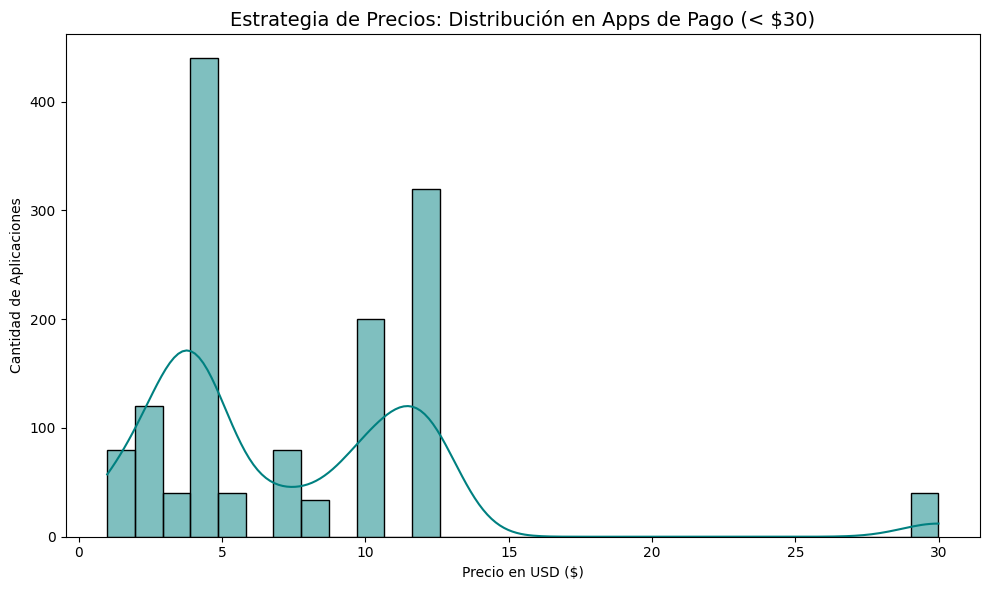

In [48]:
plt.figure(figsize=(10, 6))

# Filtramos apps que cuestan más de $0 y menos de $30 (para evitar sesgo de outliers extremos)
apps_pago_comunes = df_clean[(df_clean['Price'] > 0) & (df_clean['Price'] < 30)]

# Histograma con curva de densidad (KDE)
sns.histplot(apps_pago_comunes['Price'], bins=30, kde=True, color='teal')

plt.title('Estrategia de Precios: Distribución en Apps de Pago (< $30)', fontsize=14)
plt.xlabel('Precio en USD ($)')
plt.ylabel('Cantidad de Aplicaciones')

plt.tight_layout()
plt.show()

### 10. Métrica de Negocio Real: Estimación de Ingresos Brutos (Market Sizing)
En la industria, el precio o las instalaciones por separado no cuentan toda la historia. Si multiplicamos el Precio de la app por su Cantidad de Instalaciones, obtenemos el **Ingreso Bruto Estimado** (Estimated Revenue). Esta métrica nos permite ver qué categorías generan más dinero, no solo cuáles tienen más descargas. *(Nota: Esto solo es posible gracias a la conversión de Price e Installs a numéricos).*

/tmp/ipykernel_1243/1216552228.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ingresos_millones.values, y=ingresos_millones.index, palette='YlGnBu_r')


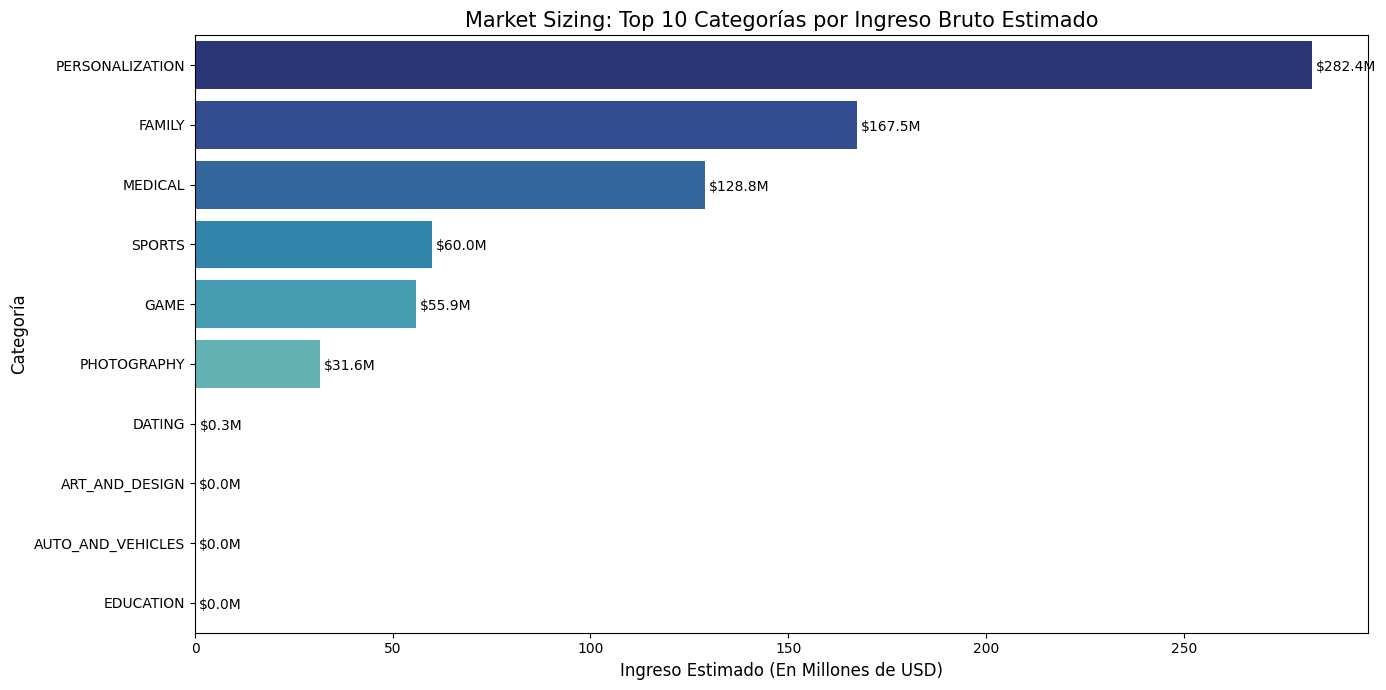

In [52]:
plt.figure(figsize=(14, 7))

# 1. Creamos la métrica real de negocio
df_copy['Estimated_Revenue'] = df_copy['Price'] * df_copy['Installs']

# 2. Agrupamos por categoría y sumamos los ingresos estimados
ingresos_por_categoria = df_copy.groupby('Category')['Estimated_Revenue'].sum().sort_values(ascending=False).head(10)

# Convertimos a millones para facilitar la lectura del gráfico
ingresos_millones = ingresos_por_categoria / 1_000_000

# 3. Graficamos
sns.barplot(x=ingresos_millones.values, y=ingresos_millones.index, palette='YlGnBu_r')

plt.title('Market Sizing: Top 10 Categorías por Ingreso Bruto Estimado', fontsize=15)
plt.xlabel('Ingreso Estimado (En Millones de USD)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Añadir los valores en las barras para mayor claridad
for i, v in enumerate(ingresos_millones.values):
    plt.text(v + 1, i + 0.1, f"${v:,.1f}M", color='black', fontsize=10)

plt.tight_layout()
plt.show()

### 11. Calidad del Producto: Polaridad de Sentimiento (Densidad KDE)
Utilizando los datos de las reseñas (`df_full`), analizamos la `Sentiment_Polarity` (una métrica NLP real que va de -1 a 1, donde -1 es muy negativo y 1 es muy positivo). Comparamos si las aplicaciones de pago tienen reseñas inherentemente más positivas que las gratuitas mediante un gráfico de densidad de Kernel (KDE).

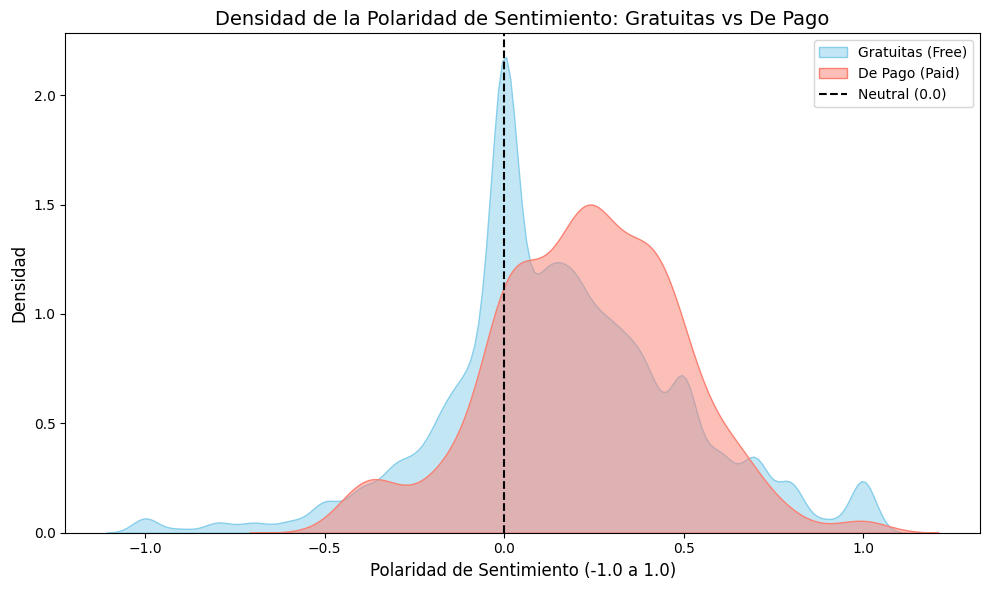

In [53]:
plt.figure(figsize=(10, 6))

# Filtramos los datos vacíos en la polaridad
df_polaridad = df_full.dropna(subset=['Sentiment_Polarity'])

# Gráfico de densidad (KDE) comparando Apps Gratuitas vs De Pago
sns.kdeplot(data=df_polaridad[df_polaridad['Type'] == 'Free']['Sentiment_Polarity'],
            label='Gratuitas (Free)', fill=True, color='skyblue', alpha=0.5)

sns.kdeplot(data=df_polaridad[df_polaridad['Type'] == 'Paid']['Sentiment_Polarity'],
            label='De Pago (Paid)', fill=True, color='salmon', alpha=0.5)

# Añadimos una línea en el 0 (Sentimiento Neutral)
plt.axvline(0, color='black', linestyle='--', label='Neutral (0.0)')

plt.title('Densidad de la Polaridad de Sentimiento: Gratuitas vs De Pago', fontsize=14)
plt.xlabel('Polaridad de Sentimiento (-1.0 a 1.0)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

### Exportación de dataset procesado

Este código final exporta el dataset que ha sido procesado en este Jupyter Notebook en dos formatos, .csv y .xlsx (excel).

In [ ]:
df_copy.to_csv('../data/googleplaystore_procesados.csv')
df_copy.to_excel('../data/googleplaystore_procesados.xlsx')